In [1]:
import numpy as np
import uproot
import pandas as pd
import Util
import matplotlib.pyplot as plt

# Chi2

Get Chi2 data

In [3]:
chi2_file_name = "/data/jchishol/mntuples_08_01_22/Results/Chi2_TestDataResults.root"

with uproot.open(chi2_file_name) as data_file:
    truth_df = data_file["parton"].arrays(library="pd")
    truth_df = truth_df.add_prefix('truth_')
    reco_df = data_file["reco"].arrays(library="pd")
    reco_df = reco_df.add_prefix('reco_')
    chi2_df = pd.concat([truth_df,reco_df], axis=1)

In [4]:
chi2_df

,truth_index,truth_th_pt,truth_th_eta,truth_th_y,truth_th_phi,truth_th_m,truth_th_E,truth_tl_pt,truth_tl_eta,truth_tl_y,...,reco_tl_m,reco_ttbar_pt,reco_ttbar_eta,reco_ttbar_y,reco_ttbar_phi,reco_ttbar_m,reco_ttbar_E,reco_eventNumber,reco_jet_n,reco_chi2
0,0,298396.468750,-1.655345,-1.523267,-0.387099,172109.671875,827629.937500,285370.500000,-1.074880,-0.954752,...,161.900009,43.041832,-3.963243,-1.356611,0.972101,623.088196,1293.035767,9003360.0,5.0,14.168345
1,1,58507.054688,3.011865,1.895328,-2.302530,172742.453125,620553.000000,69013.835938,-0.400520,-0.152617,...,150.394501,6.451531,5.130146,0.857668,-1.280194,563.985657,784.500488,9009594.0,4.0,74.265976
2,2,150567.484375,0.875857,0.612700,2.576738,172830.156250,273605.062500,131370.531250,1.323992,0.921984,...,169.681229,14.428253,2.669721,0.176092,-1.015676,585.362854,594.642517,9003049.0,4.0,11.537133
3,3,100229.750000,1.175209,0.727839,0.807193,155469.578125,236175.250000,102323.234375,1.134705,0.659144,...,209.220505,5.174862,4.616838,0.693413,-0.641029,348.812775,436.133423,9003913.0,4.0,19.341356
4,4,199048.562500,0.646724,0.501429,-0.365400,173125.515625,297669.500000,164316.656250,-0.749087,-0.538978,...,175.359528,24.709536,-0.100842,-0.004384,-1.359004,568.848389,569.390259,9003642.0,4.0,1.058431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3605896,3605896,36415.878906,-0.552733,-0.118418,-2.734588,174590.078125,179599.375000,70133.726562,-2.881558,-1.926522,...,144.867416,9.610197,-3.043265,-0.312349,1.482570,316.597687,332.320618,256311672.0,4.0,6.619503
3605897,3605897,93749.984375,-0.987200,-0.529532,-0.250278,171354.843750,223354.984375,125669.429688,-0.366254,-0.219386,...,147.521042,132.084869,-2.861827,-1.625568,-1.699258,452.627197,1244.328125,256311943.0,5.0,8.438385
3605898,3605898,102700.328125,-2.028140,-1.405017,2.023819,171908.578125,432635.312500,225566.734375,-1.304767,-1.114259,...,171.274277,50.439636,3.480123,1.106989,-1.701516,604.987122,1018.625977,256310852.0,5.0,3.398269
3605899,3605899,170457.828125,0.325820,0.231976,-0.655496,171076.562500,248028.828125,143717.703125,2.608114,2.173987,...,142.462708,67.448311,1.631134,0.536788,-3.134040,286.550598,337.821503,256311272.0,5.0,7.252862


Fix Chi2 Units

In [5]:
for var in list(['th_m','tl_m','ttbar_pt','ttbar_m']):
    chi2_df = Util.checkUnits(chi2_df,var,'GeV')

/home/jchishol/scratch_env/lib64/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


/home/jchishol/scratch_env/lib64/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
truth_th_m is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_tl_m is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_ttbar_pt is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.
truth_ttbar_m is estimated to be in units of MeV when units of GeV were set. Scaling to the latter units. Please ensure your histogram looks correct.


In [6]:
chi2_df[['truth_th_m','reco_th_m','truth_tl_m','reco_tl_m','truth_ttbar_pt','reco_ttbar_pt','truth_ttbar_m','reco_ttbar_m','reco_chi2']]

,truth_th_m,reco_th_m,truth_tl_m,reco_tl_m,truth_ttbar_pt,reco_ttbar_pt,truth_ttbar_m,reco_ttbar_m,reco_chi2
0,172.109672,124.180389,173.065641,161.900009,37.217758,43.041832,704.819500,623.088196,14.168345
1,172.742453,276.092102,171.944547,150.394501,94.696008,6.451531,567.868938,563.985657,74.265976
2,172.830156,229.590515,172.417750,169.681229,25.609889,14.428253,448.717469,585.362854,11.537133
3,155.469578,111.459229,173.635891,209.220505,9.465035,5.174862,384.263781,348.812775,19.341356
4,173.125516,163.231216,173.023812,175.359528,34.459723,24.709536,569.522312,568.848389,1.058431
...,...,...,...,...,...,...,...,...,...
3605896,174.590078,136.156754,171.867719,144.867416,34.132441,9.610197,521.744312,316.597687,6.619503
3605897,171.354844,163.712433,171.741406,147.521042,45.109629,132.084869,410.085406,452.627197,8.438385
3605898,171.908578,144.041840,171.467766,171.274277,137.424438,50.439636,468.655438,604.987122,3.398269
3605899,171.076562,135.887283,171.206281,142.462708,49.402375,67.448311,690.162625,286.550598,7.252862


Make data cuts on Chi2

In [7]:
cut_chi2_df = chi2_df[chi2_df['reco_chi2']<50]
bad_cut_chi2_df = chi2_df[chi2_df['reco_chi2']>50]

In [10]:
cut_chi2_df[['truth_th_m','reco_th_m','truth_tl_m','reco_tl_m','truth_ttbar_pt','reco_ttbar_pt','truth_ttbar_m','reco_ttbar_m','reco_chi2']]

,truth_th_m,reco_th_m,truth_tl_m,reco_tl_m,truth_ttbar_pt,reco_ttbar_pt,truth_ttbar_m,reco_ttbar_m,reco_chi2
0,172.109672,124.180389,173.065641,161.900009,37.217758,43.041832,704.819500,623.088196,14.168345
2,172.830156,229.590515,172.417750,169.681229,25.609889,14.428253,448.717469,585.362854,11.537133
3,155.469578,111.459229,173.635891,209.220505,9.465035,5.174862,384.263781,348.812775,19.341356
4,173.125516,163.231216,173.023812,175.359528,34.459723,24.709536,569.522312,568.848389,1.058431
5,172.551000,178.796570,175.821203,178.312653,143.604516,35.615406,505.784938,545.292847,0.957239
...,...,...,...,...,...,...,...,...,...
3605895,173.229484,147.786560,171.529188,184.939148,130.067352,23.072979,421.331437,504.403076,7.577649
3605896,174.590078,136.156754,171.867719,144.867416,34.132441,9.610197,521.744312,316.597687,6.619503
3605897,171.354844,163.712433,171.741406,147.521042,45.109629,132.084869,410.085406,452.627197,8.438385
3605898,171.908578,144.041840,171.467766,171.274277,137.424438,50.439636,468.655438,604.987122,3.398269


In [11]:
bad_cut_chi2_df[['truth_th_m','reco_th_m','truth_tl_m','reco_tl_m','truth_ttbar_pt','reco_ttbar_pt','truth_ttbar_m','reco_ttbar_m','reco_chi2']]

,truth_th_m,reco_th_m,truth_tl_m,reco_tl_m,truth_ttbar_pt,reco_ttbar_pt,truth_ttbar_m,reco_ttbar_m,reco_chi2
1,172.742453,276.092102,171.944547,150.394501,94.696008,6.451531,567.868938,563.985657,74.265976
13,173.039078,232.707123,171.989453,179.758865,47.846129,9.550405,498.369750,445.128021,78.132095
16,170.701547,280.918701,172.347125,173.054443,36.518559,94.944450,552.234375,647.549133,77.291740
21,170.499969,305.597748,171.540844,176.598709,21.548359,12.134445,389.531437,644.577087,105.109749
24,172.728859,186.988419,171.680281,161.830276,72.527570,28.495590,444.636406,446.175842,77.446426
...,...,...,...,...,...,...,...,...,...
3605861,169.720703,272.167572,172.814266,173.236649,20.817098,45.813892,430.166125,703.563904,201.568756
3605869,173.366719,358.643311,172.444672,321.054749,16.031996,10.828186,453.608000,953.209290,351.795746
3605887,171.742422,261.990204,172.586688,176.866272,111.755164,38.735779,386.123719,500.027679,61.808460
3605890,172.651125,335.638916,172.209250,132.910278,42.871926,74.035881,463.032125,638.168152,214.495758


Plots of chi2

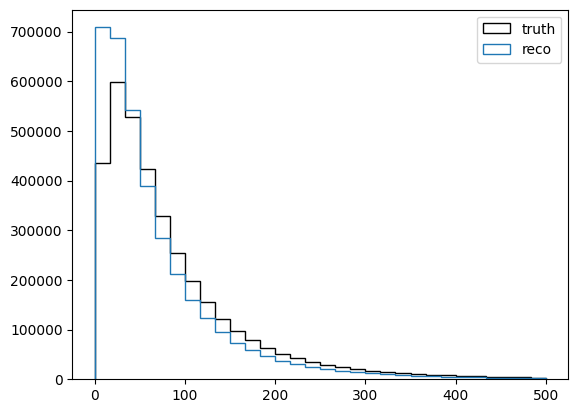

In [12]:
plt.hist(chi2_df['truth_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='truth',color='black')
plt.hist(chi2_df['reco_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='reco')
plt.legend()

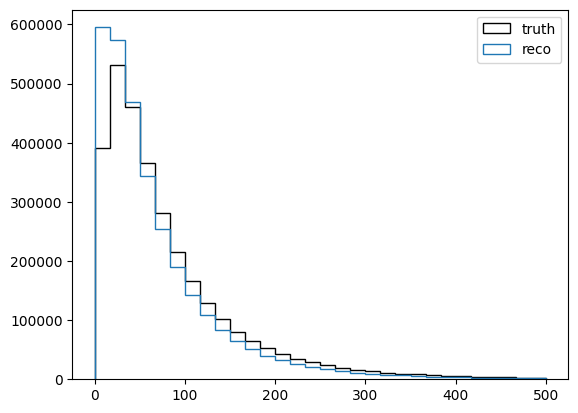

In [13]:
plt.hist(cut_chi2_df['truth_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='truth',color='black')
plt.hist(cut_chi2_df['reco_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='reco')
plt.legend()

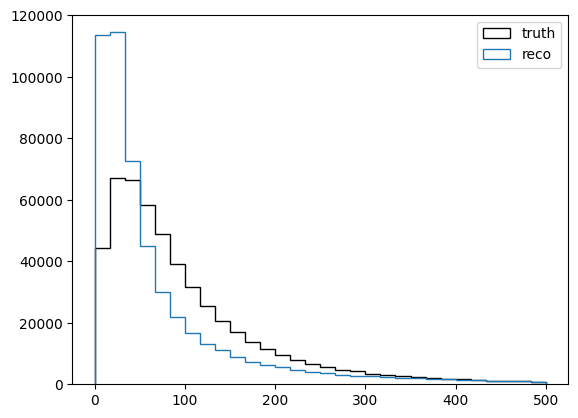

In [14]:
plt.hist(bad_cut_chi2_df['truth_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='truth',color='black')
plt.hist(bad_cut_chi2_df['reco_ttbar_pt'],range=(0,500),bins=30,histtype='step',label='reco')
plt.legend()